# Import libs


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures

In [2]:
path = "банки данные.xlsx"

# Read Data

In [3]:
df_raw = pd.read_excel(path)

In [4]:
df_raw.describe()

,Год,DIG,OE,ROA,BS,LQ
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2019.500000,0.013963,0.002811,0.009063,32.677088,0.115058
std,2.921384,0.012644,0.005326,0.002604,0.906444,0.027534
min,2015.000000,0.001200,0.000110,0.004000,30.299499,0.091642
25%,2017.000000,0.003181,0.000437,0.007500,32.181450,0.099916
50%,2019.500000,0.008466,0.000805,0.008350,33.040059,0.099993
75%,2022.000000,0.026822,0.001781,0.010675,33.332038,0.119751
max,2024.000000,0.035194,0.019051,0.015100,33.623188,0.211900


In [5]:
df_raw

,Компания,Год,DIG,OE,ROA,BS,LQ
0,JPMorgan Chase,2024,0.035036,0.000249,0.0138,33.623188,0.091642
1,JPMorgan Chase,2023,0.032295,0.000222,0.0124,33.590838,0.119917
2,JPMorgan Chase,2022,0.031961,0.000180,0.0092,30.788745,0.099992
3,JPMorgan Chase,2021,0.033857,0.000110,0.0092,33.148863,0.106404
4,JPMorgan Chase,2020,0.033376,0.001913,0.0088,30.863247,0.099988
5,JPMorgan Chase,2019,0.035194,0.018902,0.0118,33.200331,0.099992
6,JPMorgan Chase,2018,0.031901,0.000177,0.0127,33.224758,0.100000
7,JPMorgan Chase,2017,0.028047,0.001756,0.0084,33.455474,0.099994
8,JPMorgan Chase,2016,0.023147,0.001764,0.0125,33.556231,0.099754
9,JPMorgan Chase,2015,0.021312,0.001772,0.0094,33.535222,0.099944


In [6]:
df_raw.columns

Index(['Компания ', 'Год ', 'DIG', 'OE', 'ROA', 'BS', 'LQ'], dtype='object')

In [7]:
df = df_raw.drop(axis=1, columns=["Компания ", "Год "], inplace=False)

In [8]:
df.head()

,DIG,OE,ROA,BS,LQ
0,0.035036,0.000249,0.0138,33.623188,0.091642
1,0.032295,0.000222,0.0124,33.590838,0.119917
2,0.031961,0.000180,0.0092,30.788745,0.099992
3,0.033857,0.000110,0.0092,33.148863,0.106404
4,0.033376,0.001913,0.0088,30.863247,0.099988


# Define functions to plot correlations Spearman, Kendal, Pearson

In [9]:
def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=col_labels,
                  rotation=-30, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(data.shape[0]), labels=row_labels)

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

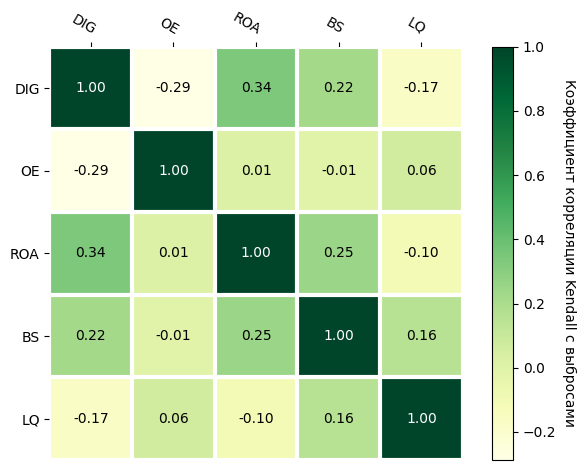

In [10]:
fig, ax = plt.subplots()

im, cbar = heatmap(df.corr(method="kendall").to_numpy(), df.corr().columns.to_list(), list(df.corr()), ax=ax,
                   cmap="YlGn", cbarlabel="Коэффициент корреляции Kendall с выбросами")
texts = annotate_heatmap(im, valfmt="{x:.2f}")

fig.tight_layout()
plt.show()



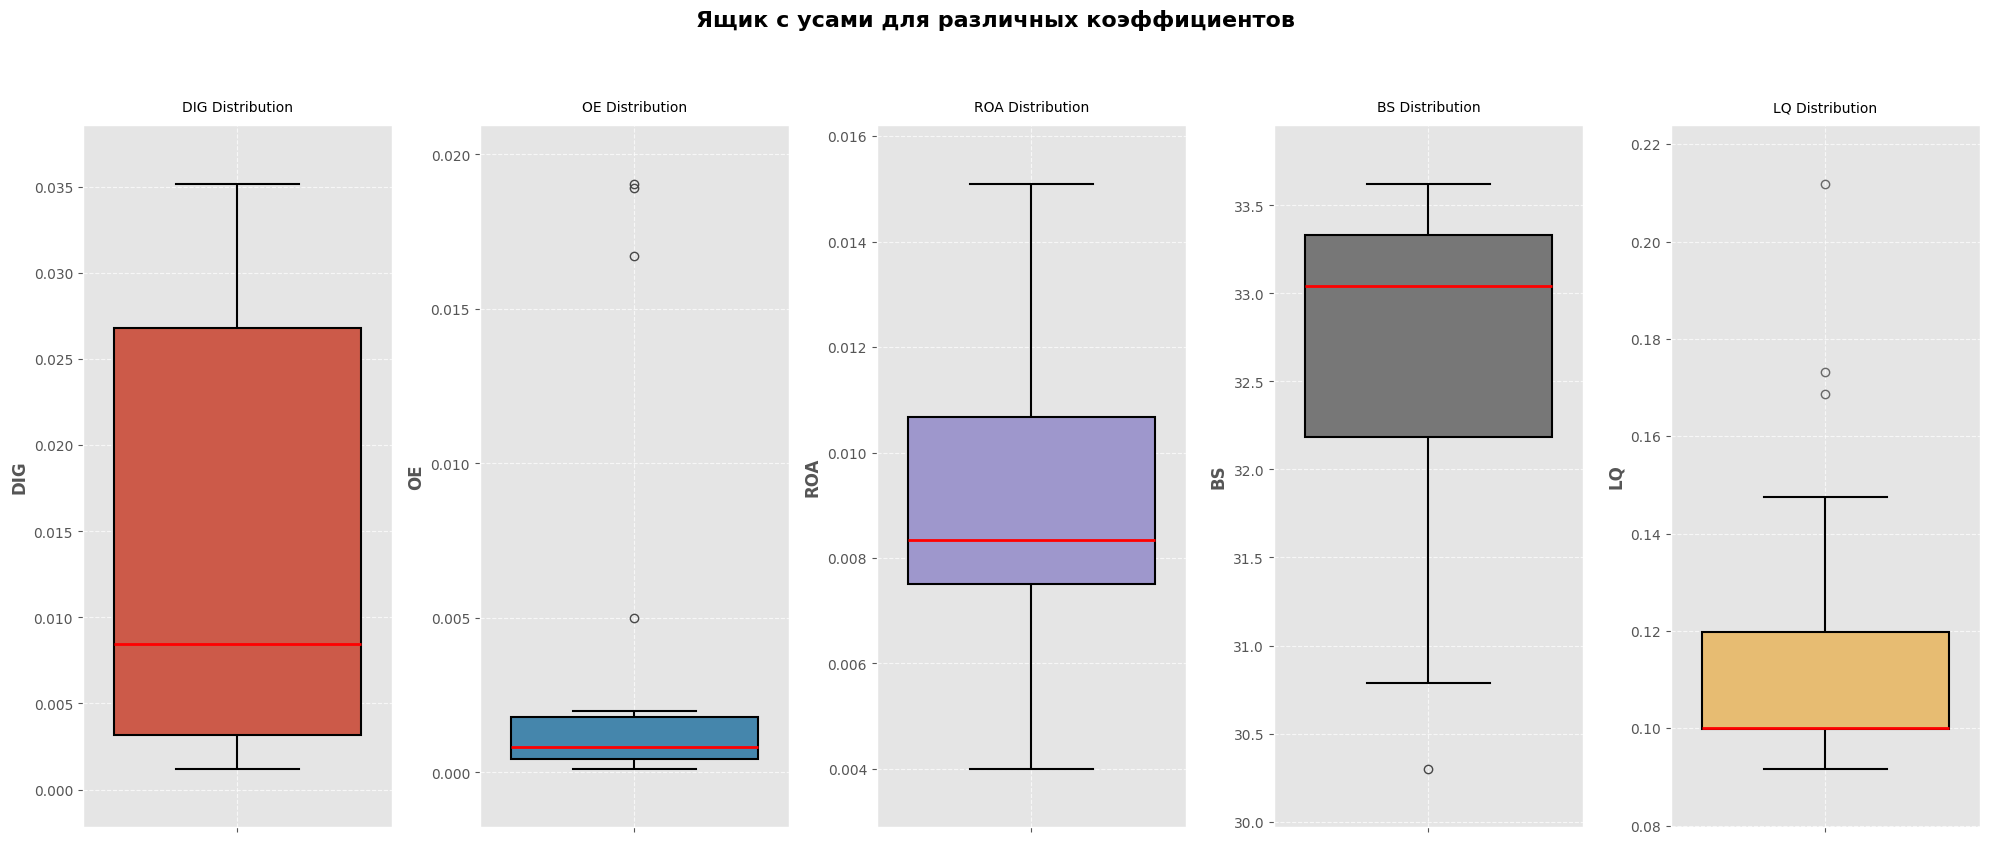

In [11]:
plt.style.use('ggplot')  # Updated Seaborn style

# Create subplots (1 row, one plot per column)
fig, axes = plt.subplots(1, len(df.columns), figsize=(20, 8), dpi=100)

# Add a super title
fig.suptitle('Ящик с усами для различных коэффициентов', fontsize=16, weight='bold', y=1.05)

# Customize each boxplot
for i, col in enumerate(df.columns):
    ax = axes[i] if len(df.columns) > 1 else axes  # Handle single-column case
    sns.boxplot(y=df[col], ax=ax, 
                color=f'C{i}',  # Unique color per boxplot
                boxprops=dict(edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                medianprops=dict(color='red', linewidth=2))  # Highlight median
    
    # Set y-limits dynamically with padding
    col_min, col_max = df[col].min(), df[col].max()
    padding = (col_max - col_min) * 0.1  # 10% padding
    ax.set_ylim(col_min - padding, col_max + padding)
    
    # Labels and styling
    ax.set_ylabel(col, fontsize=12, weight='bold')
    ax.set_title(f'{col} Distribution', fontsize=10, pad=10)
    ax.grid(True, linestyle='--', alpha=0.7)  # Subtle grid
    
    # Rotate x-axis labels if needed (for readability, though boxplot has no x-ticks here)
    ax.tick_params(axis='y', labelsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

# Define Simple LinearReg

https://stackoverflow.com/questions/66870802/scipy-how-to-minimize-the-minimum-residual-sum-of-squares-with-constraint

https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

In [12]:
# import numpy as np
# from scipy.optimize import minimize
# from tqdm import tqdm

# def f(x0, x):
#     """
#     x0: Parameters [8,] 
#     x: Input features (72, 5)
#     Returns: Predictions (72,)
#     """
#     return (
#         x0[0]                             # Intercept
#         + x0[1] * x[:, 0]                 # AI_Score 
#         + x0[2] * x[:, 1]                 # R&D
#         + x0[3] * x[:, 0] * x[:, 1]       # AI_Score * R&D
#         + x0[4] * x[:, 2]                 # F_SIZ
#         + x0[5] * x[:, 3]                 # LEV
#         + x0[6] * x[:, 4]                 # F_AGE
#         + x0[7]                           # Additional bias
#     )

# # The objective Function to minimize (least-squares regression)
# def obj(x0, x, y):
#     return np.sum((y - f(x0, x.to_numpy()))**2)

import numpy as np
from scipy.optimize import minimize
from tqdm import tqdm

def f(x0, x):
    """
    x0: Parameters [5,] 
    x: Input features (29, 4)
    Returns: Predictions (72,)
    """
    return (
        x0[0]                             # Intercept
        + x0[1] * x[:, 0]                 # DIG
        + x0[2] * x[:, 1]                 # OE
        + x0[3] * x[:, 2]                 # BS
        + x0[4] * x[:, 3]                 # LQ
    )

# The objective Function to minimize (least-squares regression)
def obj(x0, x, y):
    return np.sum((y - f(x0, x.to_numpy()))**2)

In [13]:
def normalized(df: pd.DataFrame) -> pd.DataFrame:
    return (df - df.mean()) / df.std()

In [18]:
y = np.exp(df["ROA"])
X = np.exp(df.drop(axis=0, columns=["ROA"], inplace=False)[["DIG", "OE", "BS", "LQ"]])

In [22]:
X["BS"] = np.log(X["BS"]) # invert exp

In [23]:
X

,DIG,OE,BS,LQ
0,1.035657,1.000249,3.515216,1.095973
1,1.032822,1.000222,3.514253,1.127403
2,1.032477,1.000180,3.427149,1.105162
3,1.034436,1.000110,3.501008,1.112272
4,1.033939,1.001915,3.429566,1.105158
5,1.035821,1.019082,3.502560,1.105162
6,1.032415,1.000177,3.503295,1.105171
7,1.028444,1.001757,3.510215,1.105165
8,1.023417,1.001766,3.513223,1.104899
9,1.021541,1.001773,3.512596,1.105109


In [24]:
# def do_experiment(X, y, n_experiments: int = 1000, initial_guess_size: int = 5) -> list:
#     # Minimize the objective function
#     results = []
#     for i in tqdm(range(n_experiments)):
#         initial_guess = np.random.uniform(-5.72, 0.99, size=initial_guess_size)
#         result = minimize(obj, initial_guess, args=(X, y), method='L-BFGS-B')
#         results.append(result.x)
#     return results

# results = do_experiment(X, y, 10000)

from multiprocessing import Pool
import numpy as np
from scipy.optimize import minimize
from tqdm import tqdm

def run_single_experiment(args):
    obj, X, y, initial_guess_size = args
    initial_guess = np.random.uniform(-5.72, 0.99, size=initial_guess_size)
    result = minimize(obj, initial_guess, args=(X, y), method='L-BFGS-B')
    return result.x

def do_experiment_parallel(X, y, n_experiments: int = 1000, initial_guess_size: int = 5, n_workers: int = None) -> list:
    # Create a pool of workers
    with Pool(processes=n_workers) as pool:
        # Prepare arguments for each experiment
        args = [(obj, X, y, initial_guess_size) for _ in range(n_experiments)]
        
        # Use imap_unordered for faster execution with tqdm progress bar
        results = list(tqdm(pool.imap_unordered(run_single_experiment, args), 
                         total=n_experiments))
    
    return results

In [25]:
results = do_experiment_parallel(X, y, 10000, 5, 5)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:54<00:00, 87.64it/s]


In [26]:
df_roa = pd.DataFrame(np.array([np.array(results).T.mean(axis=1),
                      np.array(results).T.std(axis=1),]), index=["mean", "std"],
             columns=["alpha_0", "beta_1", "beta_2", "beta_3", "beta_4"]).round(decimals=3)

In [27]:
print("ROA")
df_roa.head()

ROA


,alpha_0,beta_1,beta_2,beta_3,beta_4
mean,0.784,0.088,0.085,0.019,-0.014
std,0.106,0.008,0.098,0.004,0.005


# Рассчитываем коеффициент error_rate для каждой компании

In [28]:
y - f(df_roa.loc["mean"].to_numpy(), X.to_numpy())

0     0.002291
1     0.001583
2    -0.000274
3    -0.001745
4    -0.001000
5    -0.000981
6     0.001823
7    -0.002439
8     0.002085
9    -0.000870
10   -0.000309
11    0.000326
12   -0.000142
13    0.003812
14   -0.002216
15    0.002657
16    0.002428
17   -0.000731
18   -0.000703
19   -0.000926
20   -0.000917
21   -0.003910
22   -0.000214
23    0.005960
24   -0.000574
25    0.000092
26    0.002434
27   -0.003778
28    0.000382
29   -0.001250
Name: ROA, dtype: float64

In [29]:
df_raw['error_rate_by_roa'] = y - f(df_roa.loc["mean"].to_numpy(), X.to_numpy())

In [30]:
df_new_data = df_raw.fillna(method="ffill")

In [31]:
df_new_data.groupby("Компания ").mean()[["error_rate_by_roa"]]

,error_rate_by_roa
Компания,
Bank of America,0.000420
Goldman Sachs,-0.000177
JPMorgan Chase,0.000047


In [50]:
# Сохраним данные по error rate
df_new_data.to_excel("BanksofAmerica.xlsx", index=False)

In [51]:
df_new_data = pd.read_excel("BanksofAmerica.xlsx")

In [52]:
df_new_data

,Unnamed: 0,Компания,Год,DIG,OE,ROA,BS,LQ,error_rate_by_roa
0,0,JPMorgan Chase,2024,0.035036,0.000249,0.0138,33.623188,0.091642,-0.004356
1,1,JPMorgan Chase,2023,0.032295,0.000222,0.0124,33.590838,0.119917,-0.005860
2,2,JPMorgan Chase,2022,0.031961,0.000180,0.0092,30.788745,0.099992,-0.005911
3,3,JPMorgan Chase,2021,0.033857,0.000110,0.0092,33.148863,0.106404,-0.008616
4,4,JPMorgan Chase,2020,0.033376,0.001913,0.0088,30.863247,0.099988,-0.006079
5,5,JPMorgan Chase,2019,0.035194,0.018902,0.0118,33.200331,0.099992,-0.000993
6,6,JPMorgan Chase,2018,0.031901,0.000177,0.0127,33.224758,0.100000,-0.004841
7,7,JPMorgan Chase,2017,0.028047,0.001756,0.0084,33.455474,0.099994,-0.008486
8,8,JPMorgan Chase,2016,0.023147,0.001764,0.0125,33.556231,0.099754,-0.003902
9,9,JPMorgan Chase,2015,0.021312,0.001772,0.0094,33.535222,0.099944,-0.006765


In [19]:
df_new_data.drop(axis=1, columns=['Unnamed: 0'], inplace=True)

In [37]:
test = df_new_data[~df_new_data['закр'].isin(["Apple", "Google", "Johnson & Johnson", "Amazon", "Intel", "."])].drop(columns=["error_rate_by_roa", "year", "error_rate_by_roe"])

/tmp/ipykernel_4159/2217613518.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  im, cbar = heatmap(test.corr(method="pearson").to_numpy(), test.corr().columns.to_list(), list(test.corr()), ax=ax,


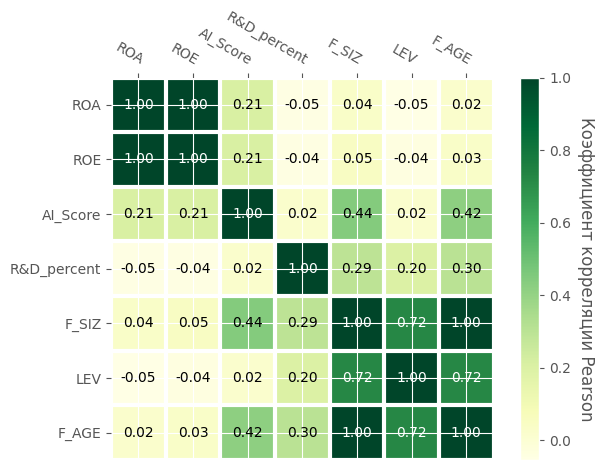

In [38]:
fig, ax = plt.subplots()

im, cbar = heatmap(test.corr(method="pearson").to_numpy(), test.corr().columns.to_list(), list(test.corr()), ax=ax,
                   cmap="YlGn", cbarlabel="Коэффициент корреляции Pearson")
texts = annotate_heatmap(im, valfmt="{x:.2f}")

fig.tight_layout()
plt.show()

In [25]:
df_new_data

,закр,year,ROA,ROE,AI_Score,R&D_percent,F_SIZ,LEV,F_AGE,error_rate_by_roe,error_rate_by_roa
0,Amazon,2024,0.1033,0.2374,0.015448,0.007512,1.142787,1.19,3.135494,-1.097931,-0.737125
1,Amazon,2023,0.0622,0.1719,0.018492,0.003676,1.156269,1.62,3.178054,-1.230379,-0.765024
2,Amazon,2022,-0.0063,-0.0198,0.007097,0.002610,1.169032,2.17,3.218876,-1.067104,-0.530277
3,Amazon,2021,0.0898,0.2798,0.004245,0.001452,1.181143,2.04,3.258097,-0.743953,-0.441459
4,Amazon,2020,0.0788,0.2707,0.000888,0.000091,1.192660,2.44,3.295837,-0.626028,-0.316304
...,...,...,...,...,...,...,...,...,...,...,...
67,Shopify,2021,0.2347,0.2791,0.001090,0.003260,0.996229,0.20,2.708050,-0.419962,-0.298037
68,Shopify,2020,0.0538,0.0632,0.001180,0.002915,0.970422,0.21,2.639057,-0.522000,-0.393515
69,Shopify,2019,-0.0433,-0.0494,0.000000,0.003494,0.941939,0.16,2.564949,-0.466159,-0.376074
70,Shopify,2018,-0.0338,-0.0368,0.000000,0.003318,0.910235,0.08,2.484907,-0.298045,-0.262714
